# Used Car Price Prediction Using Machine Learning

## Project Overview

This project uses machine learning to predict the selling price of used cars based on various vehicle-related features such as brand, manufacturing year, fuel type, transmission, engine, mileage, kilometers driven, ownership and seller type.

## Dataset

The dataset used in this project contains information about used cars and their selling prices.

It includes features such as:
- Car brand and model
- Manufacturing year
- Fuel type
- Transmission type
- Engine
- Maximum power
- Torque
- Number of seats
- Mileage
- Kilometers driven
- Owner type
- Seller type

The target variable of the project is `Selling_Price`.

## Data Loading

The used car dataset was loaded into a Pandas DataFrame from a CSV file.

The dataset initially contained 8,128 records and 13 columns. The dataset was then inspected to understand its structure, data types and missing values.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

In [ ]:
# Load the used car dataset

url = "https://raw.githubusercontent.com/YBIFoundation/Dataset/main/Car%20Selling%20Price.csv"

car_data = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Number of rows and columns:", car_data.shape)

In [ ]:
# Display the first 5 rows of the dataset

car_data.head()

In [ ]:
# Check the dataset information

car_data.info()

## Data Cleaning

The dataset was checked for missing values in each column.

Some columns contained missing values, so the rows containing missing data were removed. This helped ensure that the dataset was complete before performing further analysis and training the machine learning model.

After removing the missing values, the dataset contained 7,906 records.

In [ ]:
# Check how many missing values are present in each column

car_data.isnull().sum()

In [ ]:
# Remove rows with missing values

car_data = car_data.dropna()

print("Missing values removed successfully!")
print("New dataset shape:", car_data.shape)

## Exploratory Data Analysis

Exploratory Data Analysis (EDA) was performed to understand the main characteristics and patterns in the used car dataset.

Basic statistics were calculated for numerical features such as manufacturing year, number of seats, kilometers driven and selling price. Visualizations were also created to study the distribution of prices and the relationship between different vehicle characteristics and selling price.

In [ ]:
# Display basic statistical information about the dataset

car_data.describe()

In [ ]:
# Visualize the distribution of car selling prices

plt.figure(figsize=(10, 5))

sns.histplot(car_data["Selling_Price"], bins=30, kde=True)

plt.title("Distribution of Used Car Selling Prices")
plt.xlabel("Selling Price (₹)")
plt.ylabel("Number of Cars")

plt.show()

In [ ]:
# Analyze the relationship between car age and selling price

current_year = 2020
car_data["Car_Age"] = current_year - car_data["Year"]

plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=car_data,
    x="Car_Age",
    y="Selling_Price",
    alpha=0.5
)

plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price (₹)")

plt.show()

In [ ]:
# Count cars by fuel type

fuel_counts = car_data["Fuel"].value_counts()

print(fuel_counts)

plt.figure(figsize=(8, 5))

sns.barplot(x=fuel_counts.index, y=fuel_counts.values)

plt.title("Number of Cars by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")

plt.show()

In [ ]:
# Analyze cars by transmission type

transmission_counts = car_data["Transmission"].value_counts()

print(transmission_counts)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=transmission_counts.index,
    y=transmission_counts.values
)

plt.title("Number of Cars by Transmission Type")
plt.xlabel("Transmission")
plt.ylabel("Number of Cars")

plt.show()

## Feature Preparation

The dataset was prepared for machine learning by separating the input features from the target variable.

The `Selling_Price` column was used as the target variable, while the remaining columns were used as input features.

Categorical variables such as brand, fuel type, transmission, owner type and seller type were converted into numerical values using one-hot encoding.

The processed dataset was then divided into training and testing sets using an 80:20 ratio.

In [ ]:
# Separate input features (X) and target variable (y)

X = car_data.drop("Selling_Price", axis=1)
y = car_data["Selling_Price"]

print("Features and target separated successfully!")
print("Number of features:", X.shape[1])
print("Target variable: Selling_Price")

In [ ]:
# Convert categorical columns into numerical columns

X_encoded = pd.get_dummies(X, drop_first=True)

print("Categorical data converted successfully!")
print("Number of features after encoding:", X_encoded.shape[1])

In [ ]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)

print("Data split successfully!")
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

## Model Training

A Linear Regression model was selected to predict the selling price of used cars.

The model was trained using the training dataset. The training data contained 80% of the available records, while the remaining 20% was reserved for testing the model's performance.

In [39]:
# Create and train the Linear Regression model

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [40]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("First 10 predicted prices:")
print(y_pred[:10])

Predictions generated successfully!
First 10 predicted prices:
[458113.05027535 566567.43002835 193385.9337634  716156.07891607
 584975.41575401 352632.28794418 522031.10759617  80416.09424243
 347793.9377395  495094.72378636]


## Model Evaluation

The trained Linear Regression model was evaluated using the testing dataset.

Three evaluation metrics were used:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- R² Score

The model achieved an R² Score of approximately 0.967, indicating that the model explains a large portion of the variation in used car selling prices.

The Mean Absolute Error was approximately ₹74,657, which represents the average difference between the actual and predicted selling prices.

In [41]:
# Evaluate the model performance

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R2 Score:", r2)

Model Performance:
Mean Absolute Error (MAE): 74657.45970262395
Mean Squared Error (MSE): 23072907057.06798
R2 Score: 0.9668150872212348


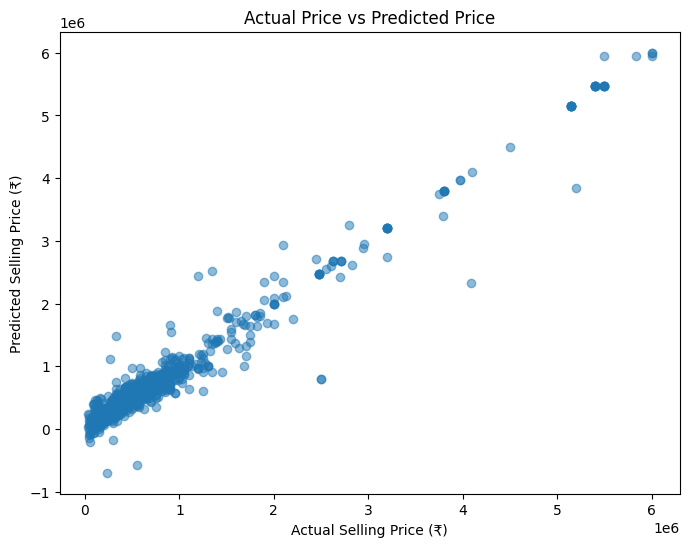

In [42]:
# Compare actual prices with predicted prices

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Selling Price (₹)")
plt.ylabel("Predicted Selling Price (₹)")
plt.title("Actual Price vs Predicted Price")

plt.show()

In [43]:
# Example prediction for a used car

sample_car = X_test.iloc[[0]]

predicted_price = model.predict(sample_car)[0]
actual_price = y_test.iloc[0]

print("Actual Selling Price: ₹", round(actual_price, 2))
print("Predicted Selling Price: ₹", round(predicted_price, 2))

Actual Selling Price: ₹ 501000
Predicted Selling Price: ₹ 458113.05


## Conclusion

In this project, a machine learning model was developed to predict the selling price of used cars.

The dataset contained information such as car brand, manufacturing year, fuel type, transmission, engine, mileage, kilometers driven, ownership and other vehicle-related features.

The data was cleaned by removing rows containing missing values. Categorical variables were converted into numerical values using one-hot encoding. The dataset was then divided into training and testing sets.

A Linear Regression model was trained using the training data and evaluated on the testing data. The model achieved an R2 Score of approximately 0.967, indicating that it was able to explain a large portion of the variation in used car selling prices.

The project demonstrates how machine learning can be applied to estimate used car prices based on historical vehicle data.

## Project Summary

### Objective
The objective of this project was to develop a machine learning model that can predict the selling price of used cars based on various vehicle-related features.

### Methodology
The dataset was cleaned by handling missing values. Categorical features were converted into numerical features using one-hot encoding. The dataset was divided into training and testing sets using an 80:20 ratio.

A Linear Regression model was then trained using the training dataset and evaluated using the testing dataset.

### Results
The model achieved an R2 Score of approximately 0.967 on the test dataset. The Mean Absolute Error (MAE) was approximately ₹74,657.

### Conclusion
The project demonstrates how machine learning can be used to estimate used car prices using historical vehicle data. The model provides reasonably accurate predictions and shows the relationship between vehicle characteristics and selling prices.

### Limitations
The accuracy of the model depends on the quality and characteristics of the dataset. Real-world used car prices can also depend on factors such as vehicle condition, location, service history, accident history and market demand, which may not be fully represented in the dataset.

In [45]:
# Predict the price of a user-defined used car

# Enter car details
brand = input("Enter car brand/model: ")
year = int(input("Enter manufacturing year: "))
fuel = input("Enter fuel type (Diesel/Petrol/CNG/LPG): ")
transmission = input("Enter transmission (Manual/Automatic): ")
engine = input("Enter engine (example: 1248 CC): ")
max_power = input("Enter max power (example: 74 bhp): ")
torque = input("Enter torque (example: 190Nm@ 2000rpm): ")
seats = float(input("Enter number of seats: "))
mileage = input("Enter mileage (example: 23.4 kmpl): ")
km_driven = int(input("Enter kilometers driven: "))
owner = input("Enter owner type (First Owner/Second Owner/Third Owner): ")
seller_type = input("Enter seller type (Individual/Dealer/Trustmark Dealer): ")

# Create a dataframe using the entered details
user_car = pd.DataFrame([{
    "Brand": brand,
    "Year": year,
    "Fuel": fuel,
    "Transmission": transmission,
    "Engine": engine,
    "Max_Power": max_power,
    "Torque": torque,
    "Seats": seats,
    "Mileage": mileage,
    "KM_Driven": km_driven,
    "Owner": owner,
    "Seller_Type": seller_type
}])

# Convert categorical data into the same format used during training
user_car_encoded = pd.get_dummies(user_car, drop_first=True)

# Make sure the columns match the training data
user_car_encoded = user_car_encoded.reindex(
    columns=X_encoded.columns,
    fill_value=0
)

# Predict the selling price
user_prediction = model.predict(user_car_encoded)[0]

print("\n--------------------------------")
print("Predicted Used Car Selling Price")
print("--------------------------------")
print("₹", round(user_prediction, 2))

Enter car brand/model: tata tiago
Enter manufacturing year: 2015
Enter fuel type (Diesel/Petrol/CNG/LPG): petrol
Enter transmission (Manual/Automatic): manual
Enter engine (example: 1248 CC): 1200cc
Enter max power (example: 74 bhp): 85 
Enter torque (example: 190Nm@ 2000rpm): 190Nm 2000rpm
Enter number of seats: 5
Enter mileage (example: 23.4 kmpl): 19 kmpl
Enter kilometers driven: 10000
Enter owner type (First Owner/Second Owner/Third Owner): first
Enter seller type (Individual/Dealer/Trustmark Dealer): individual

--------------------------------
Predicted Used Car Selling Price
--------------------------------
₹ 1099047.64
